In [1]:
# Load libraries
library(tidyverse)

# Source the scenario classification functions
source("scenario_classification.R")

# Load combined scenario data
scenario_data <- get_combined_scenario_data()

# Quick overview
cat("Date range:", as.character(min(scenario_data$date)), "to", as.character(max(scenario_data$date)), "\n")
cat("Total observations:", nrow(scenario_data), "\n")
cat("Observations with euphotic depth:", sum(!is.na(scenario_data$euphotic_depth_obs)), "\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Lade nötiges Paket: gsw



Date range: 1995-11-08 to 2017-01-17 
Total observations: 257 
Observations with euphotic depth: 102 


In [8]:
# Summary statistics by binary upwelling classification
print(summarize_by_upwelling(scenario_data))

# A tibble: 2 × 11
  upwelling     n mean_iso21 sd_iso21 mean_MLD sd_MLD mean_sst mean_temp_50m
  <chr>     <int>      <dbl>    <dbl>    <dbl>  <dbl>    <dbl>         <dbl>
1 relaxed     142      110.      16.3     20.9   7.37     26.9          23.7
2 upwelling    87       59.3     21.4     24.1   9.89     24.1          21.2
# ℹ 3 more variables: mean_euphotic_obs <dbl>, sd_euphotic_obs <dbl>,
#   n_euphotic_obs <int>


In [9]:
# Summary statistics by 4-level upwelling index
print(summarize_by_ui(scenario_data))

# A tibble: 4 × 7
  ui           n mean_iso21 sd_iso21 mean_euphotic_obs sd_euphotic_obs
  <fct>    <int>      <dbl>    <dbl>             <dbl>           <dbl>
1 strong       4       23.5     3.70              14.4            2.83
2 moderate    33       41.8     7.44              34.6           12.8 
3 weak        50       73.8    15.5               37.4            9.66
4 relaxed    142      110.     16.3               51.0            9.40
# ℹ 1 more variable: n_euphotic_obs <int>


In [4]:
# Filter to dates with both measurements
cor_data <- scenario_data %>%
  filter(!is.na(euphotic_depth_obs) & !is.na(Isotherm_21))

cat("n =", nrow(cor_data), "paired observations\n\n")

# Correlation test
cor_test <- cor.test(cor_data$euphotic_depth_obs, cor_data$Isotherm_21)
print(cor_test)

n = 94 paired observations


	Pearson's product-moment correlation

data:  cor_data$euphotic_depth_obs and cor_data$Isotherm_21
t = 8.0154, df = 92, p-value = 3.346e-12
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.5041178 0.7468227
sample estimates:
     cor 
0.641237 



`geom_smooth()` using formula = 'y ~ x'


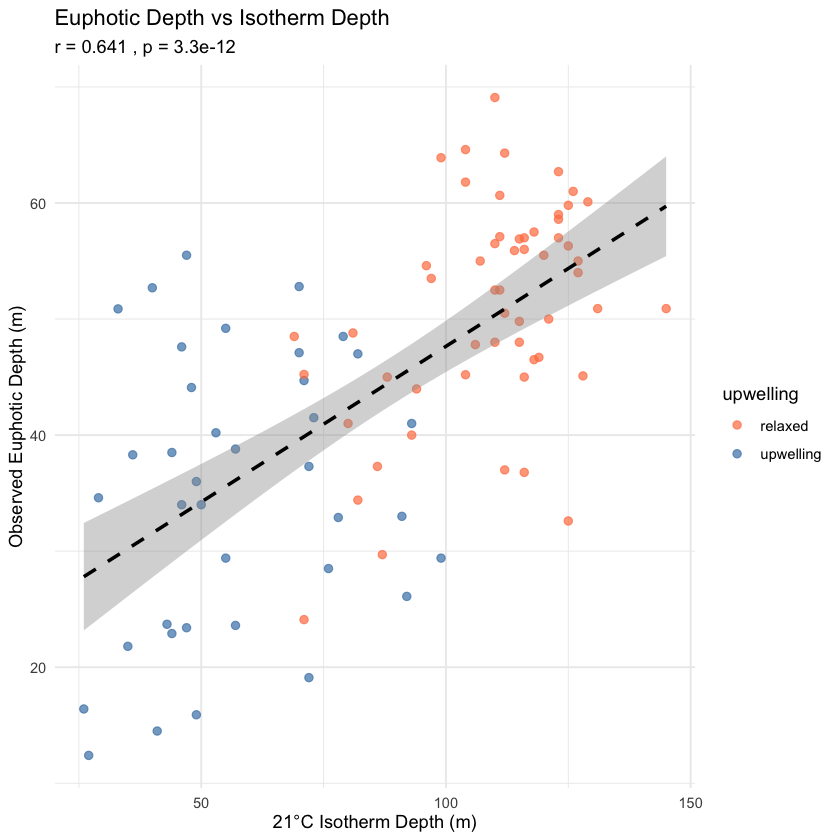

In [5]:
ggplot(cor_data, aes(x = Isotherm_21, y = euphotic_depth_obs)) +
  geom_point(aes(color = upwelling), alpha = 0.7, size = 2) +
  geom_smooth(method = "lm", se = TRUE, color = "black", linetype = "dashed") +
  labs(
    x = "21°C Isotherm Depth (m)",
    y = "Observed Euphotic Depth (m)",
    title = "Euphotic Depth vs Isotherm Depth",
    subtitle = paste("r =", round(cor_test$estimate, 3), ", p =", format.pval(cor_test$p.value, digits = 2))
  ) +
  scale_color_manual(values = c("upwelling" = "steelblue", "relaxed" = "coral")) +
  theme_minimal()

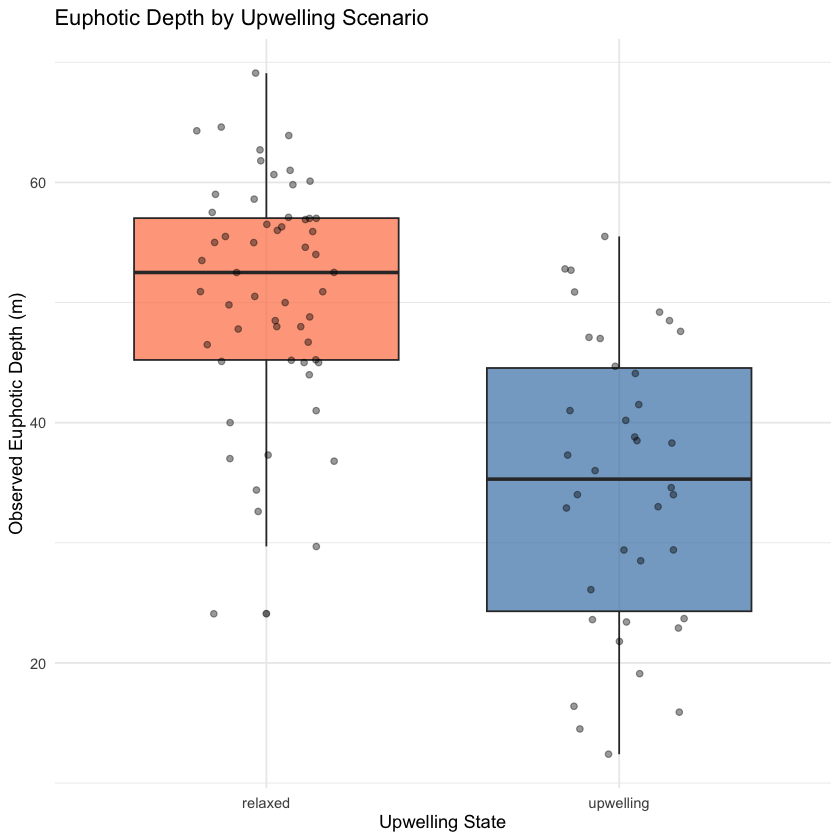

In [6]:
# Boxplot of observed euphotic depth by upwelling class
scenario_data %>%
  filter(!is.na(euphotic_depth_obs) & !is.na(upwelling)) %>%
  ggplot(aes(x = upwelling, y = euphotic_depth_obs, fill = upwelling)) +
  geom_boxplot(alpha = 0.7) +
  geom_jitter(width = 0.2, alpha = 0.4) +
  labs(
    x = "Upwelling State",
    y = "Observed Euphotic Depth (m)",
    title = "Euphotic Depth by Upwelling Scenario"
  ) +
  scale_fill_manual(values = c("upwelling" = "steelblue", "relaxed" = "coral")) +
  theme_minimal() +
  theme(legend.position = "none")

In [7]:
# Welch t-test for euphotic depth between upwelling states
euz_upwelling <- scenario_data %>% 
  filter(upwelling == "upwelling" & !is.na(euphotic_depth_obs)) %>% 
  pull(euphotic_depth_obs)

euz_relaxed <- scenario_data %>% 
  filter(upwelling == "relaxed" & !is.na(euphotic_depth_obs)) %>% 
  pull(euphotic_depth_obs)

cat("Upwelling: mean =", round(mean(euz_upwelling), 1), "m, n =", length(euz_upwelling), "\n")
cat("Relaxed:   mean =", round(mean(euz_relaxed), 1), "m, n =", length(euz_relaxed), "\n\n")

t.test(euz_upwelling, euz_relaxed)

Upwelling: mean = 34.9 m, n = 38 
Relaxed:   mean = 51 m, n = 56 




	Welch Two Sample t-test

data:  euz_upwelling and euz_relaxed
t = -6.975, df = 66.809, p-value = 1.701e-09
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -20.69755 -11.48690
sample estimates:
mean of x mean of y 
 34.92810  51.02032 
